1. На основе учебного ноутбука, проведите финальную подготовку данных. измените количество сегментирующих классов с `16` на `7`
 - 0_класс - FLOOR
 - 1_класс - CEILING
 - 2_класс - WALL
 - 3_класс - APERTURE, DOOR, WINDOW
 - 4_класс - COLUMN, RAILINGS, LADDER
 - 5_класс - INVENTORY
 - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Реализуйте сегментацию базы Стройка на основе модели `PSPnet`. Статья для изучения [Pyramid Scene Parsing Network](https://hszhao.github.io/projects/pspnet/) .


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

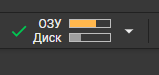


Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка


### Импорт библиотек

In [1]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [2]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:23<00:00, 9.05MB/s]


## Решение

### Шаг 1. Что такое PSPNet и зачем

**PSPNet (Pyramid Scene Parsing Network, Zhao et al., CVPR 2017)** решает ту же задачу семантической сегментации, что и U-Net, но другим способом. Главная идея — **глобальный контекст сцены**.

У обычной свёрточной сети есть проблема: receptive field у нейрона ограничен, и сеть «не видит» дальнего контекста. PSPNet добавляет поверх feature-карты от backbone специальный модуль:

**Pyramid Pooling Module (PPM)** — параллельные `AveragePooling2D` с разными «квадратами» (обычно 1×1, 2×2, 3×3, 6×6), каждый из которых:
1. усредняет feature-карту по своей сетке (получая «глобальный» контекст);
2. сжимается `1×1 Conv` (уменьшая число каналов);
3. поднимается обратно `UpSampling2D` до размера исходной feature-карты;
4. **конкатенируется** с исходной картой.

После этого `Conv → BN → ReLU` объединяет всё в единое представление, и финальный `UpSampling2D` поднимает результат до полного разрешения входа.

```
Input → Backbone (downsampling x8) → ┌─ AvgPool 1x1 → 1x1 Conv → Upsample ┐
                                     ├─ AvgPool 2x2 → 1x1 Conv → Upsample ┤── Concatenate → Conv → Upsample x8 → Softmax
                                     ├─ AvgPool 3x3 → 1x1 Conv → Upsample ┤
                                     └─ AvgPool 6x6 → 1x1 Conv → Upsample ┘
```

**Отличия от U-Net:**

| | U-Net | PSPNet |
|---|---|---|
| Декодер | симметричный, с skip-connections | один большой апсемплинг + PPM |
| Глобальный контекст | через bottleneck | явно через пирамиду pooling-ов |
| Параметров | средне | обычно меньше (с лёгким backbone) |
| Сильная сторона | мелкие детали | сцены, фоны, большие объекты |

Ниже:
- **Шаг 2** — подготовка данных (16 → 7 классов) с агрессивной экономией ОЗУ;
- **Шаг 3** — backbone (4 уровня downsampling, x8) + PPM + декодер;
- **Шаг 4** — обучение с EarlyStopping / ReduceLROnPlateau;
- **Шаг 5** — графики, IoU по каждому классу, визуализация предсказаний.

---

### Шаг 2. Загрузка изображений + подготовка (16 → 7 классов)


In [3]:
# ============================================================
# ШАГ 2. ЗАГРУЗКА ИЗОБРАЖЕНИЙ + 16 -> 7 классов
# ============================================================
# Ноутбук Ultra Pro изначально не содержит ячеек чтения файлов,
# поэтому делаем это здесь.

import numpy as np
import gc
import tensorflow as tf

# --- Параметры ---
IMG_WIDTH  = 192
IMG_HEIGHT = 256
TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY   = 'val'

NUM_CLASSES = 7
CLASS_NAMES = ['FLOOR', 'CEILING', 'WALL', 'APERTURE', 'SUPPORT', 'INVENTORY', 'OTHER']

# --- Загрузка картинок (как в учебном ноутбуке, но сразу в uint8 numpy) ---
def load_images(folder_subpath):
    """Читает все картинки из папки, возвращает uint8-массив (N, H, W, 3)."""
    files = sorted(os.listdir(folder_subpath))
    arrs = []
    for fn in files:
        img = image.load_img(os.path.join(folder_subpath, fn),
                             target_size=(IMG_WIDTH, IMG_HEIGHT))
        a = np.asarray(img, dtype=np.uint8)
        if a.ndim == 2:        a = np.stack([a]*3, axis=-1)
        if a.shape[-1] == 4:   a = a[..., :3]
        arrs.append(a)
    return np.stack(arrs, axis=0)

print('Загружаем train/original...')
t0 = time.time()
x_train = load_images(TRAIN_DIRECTORY + '/original')
print(f'  x_train: {x_train.shape} {x_train.dtype}  (за {time.time()-t0:.1f}с)')

print('Загружаем val/original...')
t0 = time.time()
x_val = load_images(VAL_DIRECTORY + '/original')
print(f'  x_val:   {x_val.shape} {x_val.dtype}  (за {time.time()-t0:.1f}с)')

# --- Палитра 16 классов и маппинг 16 -> 7 ---
CLASS_COLORS_16 = [
    (0,   0,   0),    # 0
    (128, 0,   0),    # 1
    (0,   128, 0),    # 2
    (128, 128, 0),    # 3
    (0,   0,   128),  # 4
    (128, 0,   128),  # 5
    (0,   128, 128),  # 6
    (128, 128, 128),  # 7
    (64,  0,   0),    # 8
    (192, 0,   0),    # 9
    (64,  128, 0),    # 10
    (192, 128, 0),    # 11
    (64,  0,   128),  # 12
    (192, 0,   128),  # 13
    (64,  128, 128),  # 14
    (192, 128, 128),  # 15
]

# 7 целевых классов: FLOOR, CEILING, WALL, APERTURE, SUPPORT, INVENTORY, OTHER
MAP_16_TO_7 = np.array([
    0,            # 0
    1, 1,         # 1-2
    2, 2, 2,      # 3-5
    3, 3, 3,      # 6-8
    4, 4,         # 9-10
    5, 5,         # 11-12
    6, 6, 6,      # 13-15
], dtype=np.int8)


def build_lut(colors):
    """LUT по 24-битному ключу: RGB -> класс 0..15 (255 = неизвестный)."""
    lut = np.full(256 ** 3, 255, dtype=np.uint8)
    for idx, (r, g, b) in enumerate(colors):
        lut[(r << 16) | (g << 8) | b] = idx
    return lut


def seg_rgb_to_class7(seg_rgb, lut):
    """RGB-маска -> карта 7 классов (H, W) int8."""
    s = np.asarray(seg_rgb, dtype=np.uint8)
    if s.ndim == 2:        s = np.stack([s]*3, axis=-1)
    if s.shape[-1] == 4:   s = s[..., :3]
    keys = ((s[...,0].astype(np.uint32) << 16) |
            (s[...,1].astype(np.uint32) << 8)  |
             s[...,2].astype(np.uint32))
    cls16 = lut[keys]
    cls16 = np.where(cls16 == 255, 0, cls16)
    return MAP_16_TO_7[cls16]


def load_segments_as_class7(folder_subpath, lut):
    files = sorted(os.listdir(folder_subpath))
    out = []
    for fn in files:
        img = image.load_img(os.path.join(folder_subpath, fn),
                             target_size=(IMG_WIDTH, IMG_HEIGHT))
        out.append(seg_rgb_to_class7(img, lut))
    return np.stack(out, axis=0)


LUT = build_lut(CLASS_COLORS_16)

# Авто-проверка палитры на одной маске
probe_path = sorted(os.listdir(TRAIN_DIRECTORY + '/segment'))[0]
probe_img = image.load_img(os.path.join(TRAIN_DIRECTORY + '/segment', probe_path),
                           target_size=(IMG_WIDTH, IMG_HEIGHT))
probe = np.asarray(probe_img, dtype=np.uint8)
if probe.shape[-1] == 4: probe = probe[..., :3]
pk = ((probe[...,0].astype(np.uint32) << 16) |
      (probe[...,1].astype(np.uint32) << 8)  |
       probe[...,2].astype(np.uint32))
known = (LUT[pk] != 255).mean()
print(f'\nИзвестных пикселей на первой маске: {known:.3f}')

if known < 0.5:
    print('  >> Стандартная палитра не подошла, определяем 16 цветов автоматически по частоте...')
    keys_all = []
    for fn in sorted(os.listdir(TRAIN_DIRECTORY + '/segment')):
        img = image.load_img(os.path.join(TRAIN_DIRECTORY + '/segment', fn),
                             target_size=(IMG_WIDTH, IMG_HEIGHT))
        a = np.asarray(img, dtype=np.uint8)
        if a.shape[-1] == 4: a = a[..., :3]
        k = ((a[...,0].astype(np.uint32) << 16) |
             (a[...,1].astype(np.uint32) << 8)  |
              a[...,2].astype(np.uint32))
        keys_all.append(k.ravel())
    keys_all = np.concatenate(keys_all)
    vals, counts = np.unique(keys_all, return_counts=True)
    top = vals[np.argsort(-counts)[:16]]
    print(f'  уникальных цветов: {len(vals)}; берём топ-16.')
    LUT = np.full(256 ** 3, 255, dtype=np.uint8)
    for idx, k in enumerate(top):
        LUT[k] = idx
    del keys_all, vals, counts, top
    gc.collect()

print('\nЧитаем сегментации и сразу маппим 16->7...')
t0 = time.time()
y_train = load_segments_as_class7(TRAIN_DIRECTORY + '/segment', LUT)
print(f'  y_train: {y_train.shape} {y_train.dtype}  (за {time.time()-t0:.1f}с)')

t0 = time.time()
y_val = load_segments_as_class7(VAL_DIRECTORY + '/segment', LUT)
print(f'  y_val:   {y_val.shape} {y_val.dtype}  (за {time.time()-t0:.1f}с)')

# Распределение классов
uniq, cnts = np.unique(y_train, return_counts=True)
total = cnts.sum()
print('\nРаспределение классов в y_train:')
for u, c in zip(uniq, cnts):
    name = CLASS_NAMES[u] if 0 <= u < len(CLASS_NAMES) else '?'
    print(f'  {u} {name:<10s}  {c:>10d}  ({100.0*c/total:5.2f}%)')

print(f'\nПамять:')
print(f'  X (uint8): {(x_train.nbytes + x_val.nbytes)/1024/1024:.1f} MB')
print(f'  Y (int8):  {(y_train.nbytes + y_val.nbytes)/1024/1024:.1f} MB')

gc.collect()


Загружаем train/original...
  x_train: (1900, 192, 256, 3) uint8  (за 0.7с)
Загружаем val/original...
  x_val:   (100, 192, 256, 3) uint8  (за 0.0с)

Известных пикселей на первой маске: 0.000
  >> Стандартная палитра не подошла, определяем 16 цветов автоматически по частоте...
  уникальных цветов: 27; берём топ-16.

Читаем сегментации и сразу маппим 16->7...
  y_train: (1900, 192, 256) int8  (за 1.4с)
  y_val:   (100, 192, 256) int8  (за 0.1с)

Распределение классов в y_train:
  0 FLOOR         47798941  (51.18%)
  1 CEILING       25679475  (27.50%)
  2 WALL          13411319  (14.36%)
  3 APERTURE       3783503  ( 4.05%)
  4 SUPPORT        1483145  ( 1.59%)
  5 INVENTORY       879546  ( 0.94%)
  6 OTHER           352871  ( 0.38%)

Память:
  X (uint8): 281.2 MB
  Y (int8):  93.8 MB


0

In [4]:
# ============================================================
# ШАГ 3. PSPNet (с нуля, без предобученного backbone)
# ============================================================
# ВАЖНО: апсемплинг в Pyramid Pooling Module делаем через UpSampling2D
# (Keras-слой), а не tf.image.resize — последнее нельзя применять к
# символьному KerasTensor внутри функциональной модели (Keras 3).

from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, AveragePooling2D, UpSampling2D,
                                     concatenate, Rescaling, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def conv_bn_act(x, filters, kernel_size=3, strides=1, activation='relu', name=None):
    x = Conv2D(filters, kernel_size, strides=strides, padding='same',
               kernel_initializer='he_normal', name=name)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    return x


def backbone(x, base=32):
    """Лёгкий 4-уровневый CNN-backbone. Понижение разрешения x8 (3 пулинга).

    Для входа 192x256:  192x256 -> 96x128 -> 48x64 -> 24x32
    Размеры feature-карты после backbone кратны 24 и делятся на нужные пулы.
    """
    x = conv_bn_act(x, base);    x = conv_bn_act(x, base)
    x = MaxPooling2D()(x)                                    # /2

    x = conv_bn_act(x, base*2);  x = conv_bn_act(x, base*2)
    x = MaxPooling2D()(x)                                    # /4

    x = conv_bn_act(x, base*4);  x = conv_bn_act(x, base*4)
    x = MaxPooling2D()(x)                                    # /8

    x = conv_bn_act(x, base*8);  x = conv_bn_act(x, base*8)  # без пулинга -> /8
    return x


def pyramid_pooling_module(x, feat_h, feat_w, pool_sizes=(1, 2, 3, 6),
                           filters_per_branch=None):
    """Pyramid Pooling Module из PSPNet (только Keras-слои).

    Для каждой ветви:
      AvgPool окном (ph, pw) -> 1x1 Conv -> BN -> ReLU -> UpSampling2D обратно.
    Затем всё конкатенируется с исходной feature-картой.
    feat_h, feat_w — известные (статические) размеры feature-карты.
    """
    C = x.shape[-1]
    if filters_per_branch is None:
        filters_per_branch = max(int(C) // len(pool_sizes), 16)

    branches = [x]  # исходная карта остаётся в выходе
    for ps in pool_sizes:
        # окно пула: делим feature-карту на сетку ps x ps
        ph = max(feat_h // ps, 1)
        pw = max(feat_w // ps, 1)

        b = AveragePooling2D(pool_size=(ph, pw), strides=(ph, pw),
                             padding='same')(x)
        b = Conv2D(filters_per_branch, 1, padding='same',
                   kernel_initializer='he_normal')(b)
        b = BatchNormalization()(b)
        b = Activation('relu')(b)

        # размер после AvgPool (ceil из-за padding='same')
        out_h = -(-feat_h // ph)   # ceil division
        out_w = -(-feat_w // pw)
        # целочисленный апсемплинг обратно до (feat_h, feat_w).
        # Подбираем кратный коэффициент; при необходимости докроем размеры ниже.
        up_h = max(feat_h // out_h, 1)
        up_w = max(feat_w // out_w, 1)
        b = UpSampling2D(size=(up_h, up_w), interpolation='bilinear')(b)
        branches.append(b)

    # После UpSampling размеры веток могут отличаться от feat на 1-2 px
    # из-за округлений. Приводим все ветки к ровно (feat_h, feat_w)
    # обрезкой/паддингом через Resizing-слой (Keras-слой, безопасен).
    from tensorflow.keras.layers import Resizing
    fixed = [branches[0]]
    for b in branches[1:]:
        fixed.append(Resizing(feat_h, feat_w, interpolation='bilinear')(b))
    return concatenate(fixed, axis=-1)


def build_pspnet(img_h, img_w, num_classes=NUM_CLASSES, base=32):
    """PSPNet: Input(uint8) -> Rescaling -> Backbone(/8) -> PPM -> Conv
       -> UpSampling x8 -> Softmax.
    """
    inp = Input(shape=(img_h, img_w, 3), dtype='uint8')
    x = Rescaling(1.0 / 255.0)(inp)

    feat = backbone(x, base=base)              # (img_h/8, img_w/8, base*8)

    # статические размеры feature-карты
    feat_h = feat.shape[1]
    feat_w = feat.shape[2]

    ppm = pyramid_pooling_module(feat, feat_h, feat_w,
                                 pool_sizes=(1, 2, 3, 6))

    x = conv_bn_act(ppm, base*4, kernel_size=3)
    x = Dropout(0.1)(x)

    # Поднимаем до исходного разрешения (x8) Keras-слоем
    x = UpSampling2D(size=(8, 8), interpolation='bilinear')(x)

    # На случай некратности входного размера 8 — финально подгоняем
    from tensorflow.keras.layers import Resizing
    x = Resizing(img_h, img_w, interpolation='bilinear')(x)

    x = conv_bn_act(x, base*2, kernel_size=3)
    out = Conv2D(num_classes, 1, activation='softmax', name='seg_out')(x)

    model = Model(inputs=inp, outputs=out, name='pspnet')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


_, IMG_H, IMG_W, _ = x_train.shape
print(f'Размер входа PSPNet: ({IMG_H}, {IMG_W}, 3)')

tf.keras.backend.clear_session(); gc.collect()
pspnet = build_pspnet(IMG_H, IMG_W, base=32)
pspnet.summary()


Размер входа PSPNet: (192, 256, 3)


Model: "pspnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 192, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 256,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 64,    │     73,856 │ max_pooling2d_1[

 Total params: 1,907,879 (7.28 MB)

 Trainable params: 1,905,063 (7.27 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [5]:
# ============================================================
# ШАГ 4. ОБУЧЕНИЕ PSPNet
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EPOCHS = 60
BATCH_SIZE = 8

# tf.data датасет с prefetch — без копирования больших тензоров
def make_ds(x, y, batch, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(512, len(x)), reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(x_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(x_val,   y_val,   BATCH_SIZE, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_pspnet.weights.h5', monitor='val_loss',
                    save_best_only=True, save_weights_only=True, verbose=0),
]

tf.keras.backend.clear_session(); gc.collect()
pspnet = build_pspnet(IMG_H, IMG_W, base=32)

history = pspnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

print('\nОбучение завершено.')
print(f"Финальная train_acc:  {history.history['accuracy'][-1]:.4f}")
print(f"Финальная val_acc:    {history.history['val_accuracy'][-1]:.4f}")
print(f"Лучшая    val_acc:    {max(history.history['val_accuracy']):.4f}")
print(f"Финальная val_loss:   {history.history['val_loss'][-1]:.4f}")
print(f"Лучшая    val_loss:   {min(history.history['val_loss']):.4f}")


Epoch 1/60
238/238 - 90s - 377ms/step - accuracy: 0.6674 - loss: 0.9368 - val_accuracy: 0.6149 - val_loss: 1.3272 - learning_rate: 0.0010
Epoch 2/60
238/238 - 32s - 136ms/step - accuracy: 0.7215 - loss: 0.7732 - val_accuracy: 0.5995 - val_loss: 1.1595 - learning_rate: 0.0010
Epoch 3/60
238/238 - 33s - 138ms/step - accuracy: 0.7483 - loss: 0.7022 - val_accuracy: 0.6160 - val_loss: 1.1109 - learning_rate: 0.0010
Epoch 4/60
238/238 - 33s - 140ms/step - accuracy: 0.7678 - loss: 0.6551 - val_accuracy: 0.6330 - val_loss: 1.1682 - learning_rate: 0.0010
Epoch 5/60
238/238 - 34s - 143ms/step - accuracy: 0.7845 - loss: 0.6139 - val_accuracy: 0.6681 - val_loss: 1.0233 - learning_rate: 0.0010
Epoch 6/60
238/238 - 34s - 145ms/step - accuracy: 0.7962 - loss: 0.5812 - val_accuracy: 0.6875 - val_loss: 0.9009 - learning_rate: 0.0010
Epoch 7/60
238/238 - 34s - 144ms/step - accuracy: 0.8020 - loss: 0.5596 - val_accuracy: 0.6095 - val_loss: 1.2148 - learning_rate: 0.0010
Epoch 8/60
238/238 - 34s - 144ms/s

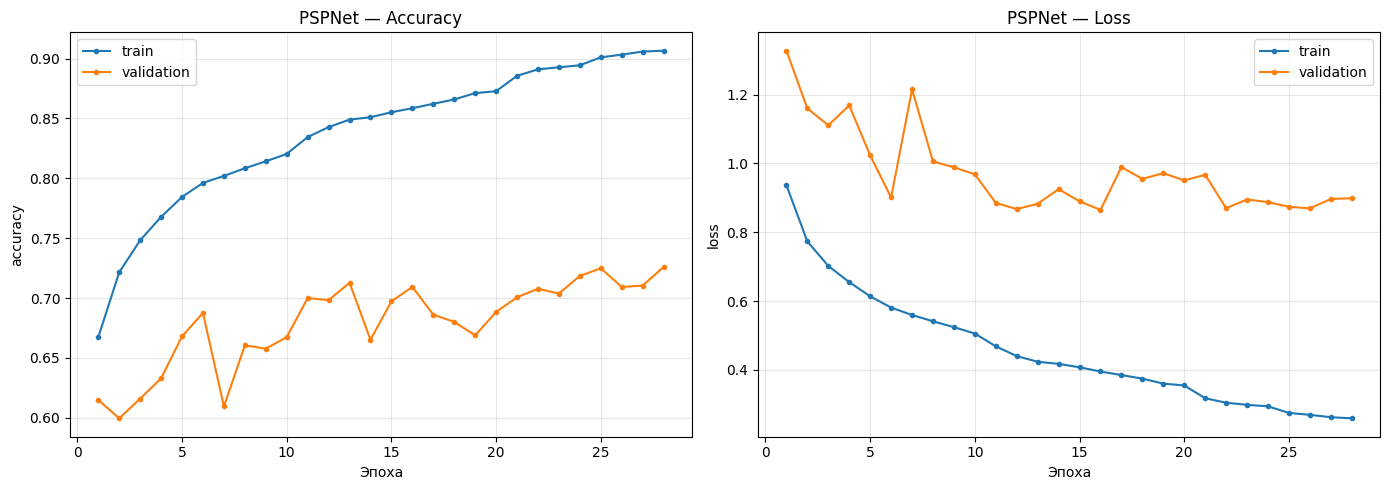

In [6]:
# ============================================================
# ШАГ 5. ГРАФИКИ ОБУЧЕНИЯ
# ============================================================
epochs_done = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_done, history.history['accuracy'],     label='train',      marker='.')
axes[0].plot(epochs_done, history.history['val_accuracy'], label='validation', marker='.')
axes[0].set_title('PSPNet — Accuracy'); axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('accuracy')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs_done, history.history['loss'],     label='train',      marker='.')
axes[1].plot(epochs_done, history.history['val_loss'], label='validation', marker='.')
axes[1].set_title('PSPNet — Loss'); axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()


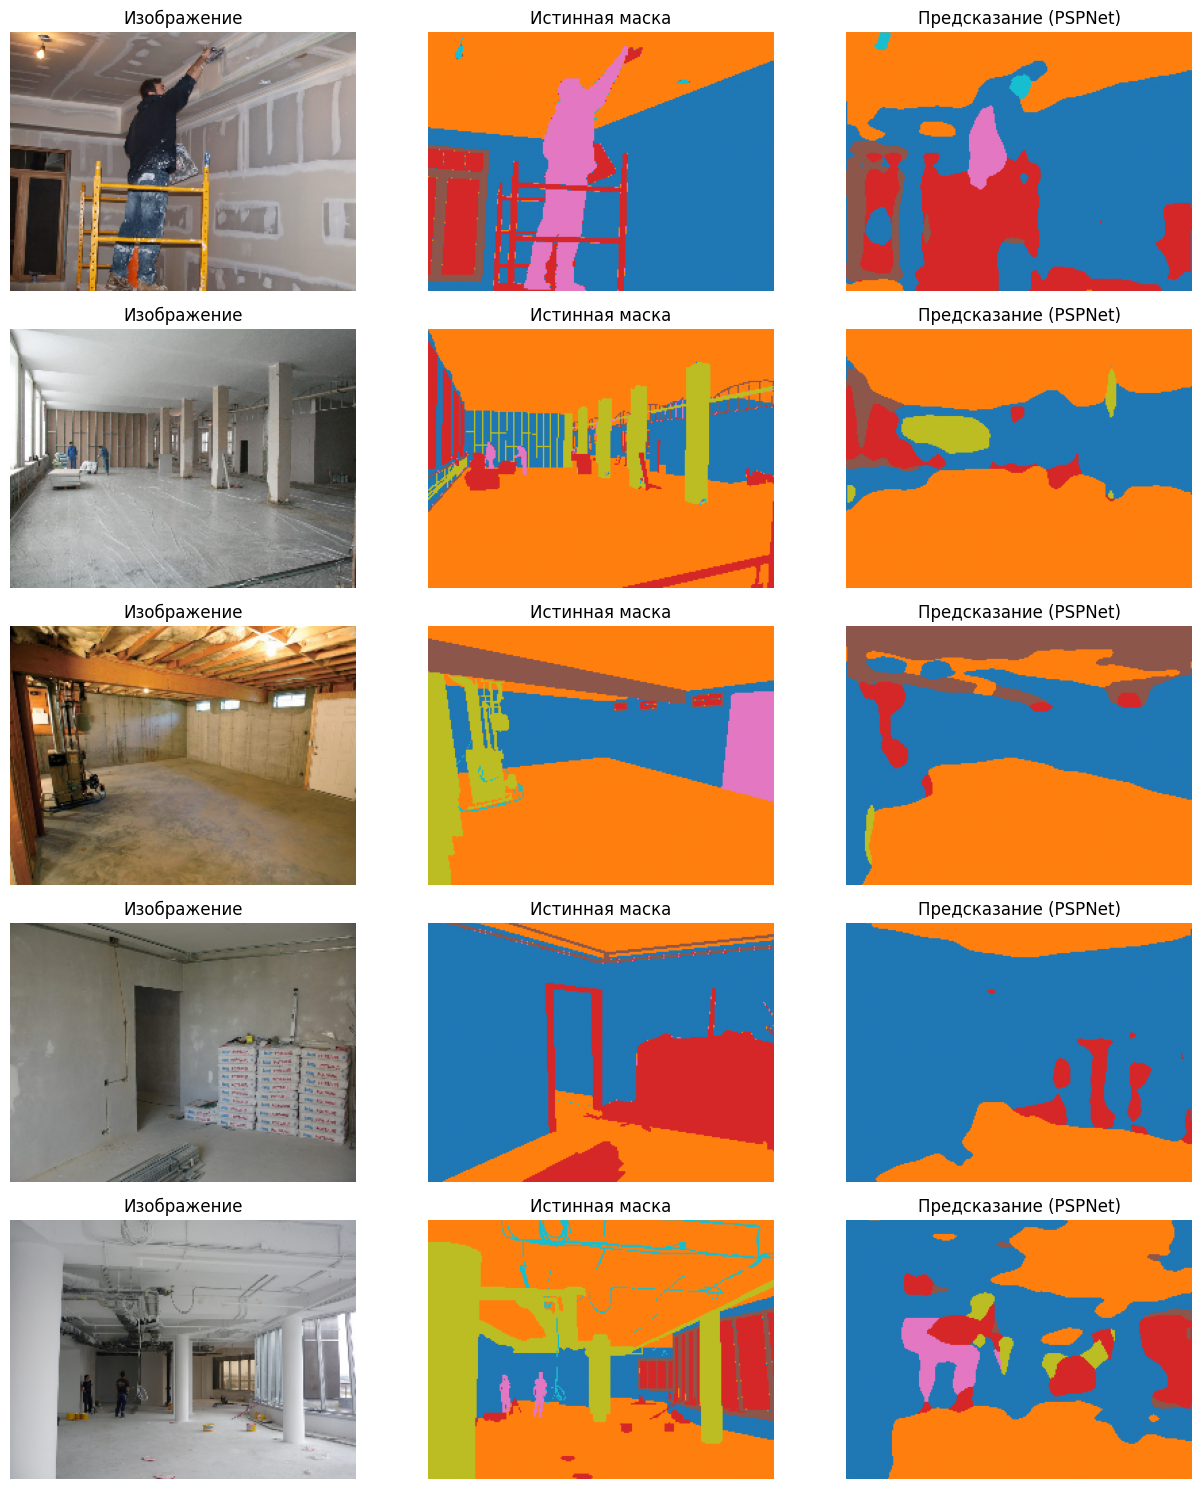


IoU по каждому классу на валидации:
  0 FLOOR       IoU = 0.6679
  1 CEILING     IoU = 0.6509
  2 WALL        IoU = 0.3150
  3 APERTURE    IoU = 0.1930
  4 SUPPORT     IoU = 0.1825
  5 INVENTORY   IoU = 0.0420
  6 OTHER       IoU = 0.0494

Mean IoU (по присутствующим классам): 0.3001


8708

In [7]:
# ============================================================
# ШАГ 6. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ + IoU ПО КЛАССАМ
# ============================================================

# --- Примеры с валидации ---
n_show = 5
idxs = np.random.choice(len(x_val), n_show, replace=False)
sample_x = x_val[idxs]
preds = pspnet.predict(sample_x, batch_size=BATCH_SIZE, verbose=0)
pred_classes = np.argmax(preds, axis=-1)
true_classes = y_val[idxs]

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3.0 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(sample_x[i]);  axes[i, 0].set_title('Изображение');  axes[i, 0].axis('off')
    axes[i, 1].imshow(true_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 1].set_title('Истинная маска'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 2].set_title('Предсказание (PSPNet)'); axes[i, 2].axis('off')
plt.tight_layout(); plt.show()

# --- IoU по каждому классу на полной валидации (батчами, чтобы не съесть память) ---
print('\nIoU по каждому классу на валидации:')
batch = 16
val_pred_all = np.empty_like(y_val)
for s in range(0, len(x_val), batch):
    p = pspnet.predict(x_val[s:s+batch], verbose=0)
    val_pred_all[s:s+batch] = np.argmax(p, axis=-1).astype(np.int8)

ious = []
for c in range(NUM_CLASSES):
    inter = np.logical_and(y_val == c, val_pred_all == c).sum()
    union = np.logical_or (y_val == c, val_pred_all == c).sum()
    iou = inter / union if union > 0 else float('nan')
    ious.append(iou)
    print(f'  {c} {CLASS_NAMES[c]:<10s}  IoU = {iou:.4f}')

valid = [v for v in ious if not np.isnan(v)]
print(f'\nMean IoU (по присутствующим классам): {np.mean(valid):.4f}')

del preds, sample_x, val_pred_all
gc.collect()
